In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("weight-height.csv")
df.head()


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [2]:
df.info()
df.describe()
df.describe(include="object")
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


,Gender
count,10000
unique,2
top,Male
freq,5000


In [3]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:
Gender    0
Height    0
Weight    0
dtype: int64

Duplicate Rows: 0


In [4]:
cat_cols = df.select_dtypes(include="object").columns
num_cols = df.select_dtypes(exclude="object").columns

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: Index(['Gender'], dtype='object')
Numerical: Index(['Height', 'Weight'], dtype='object')


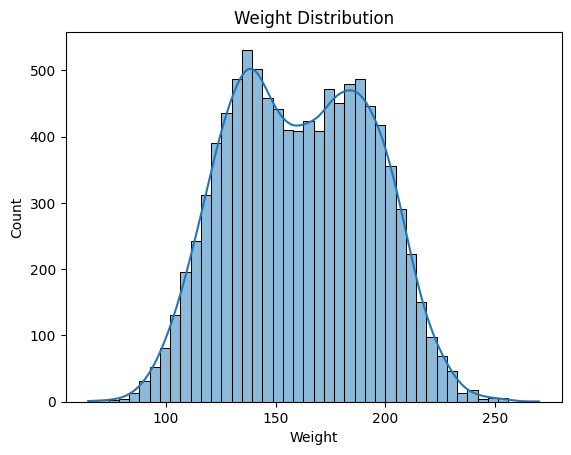

In [5]:
sns.histplot(df["Weight"], kde=True)
plt.title("Weight Distribution")
plt.show()


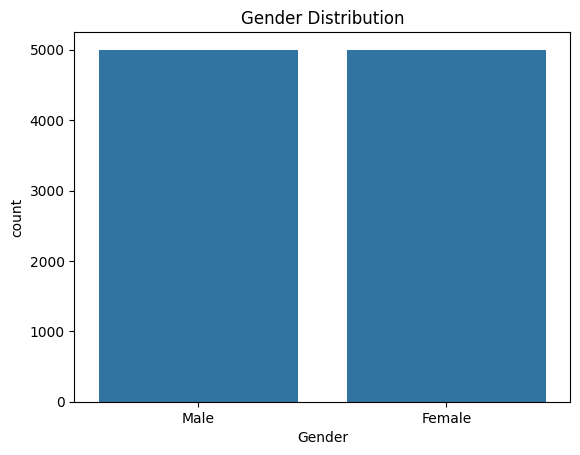

In [6]:
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()


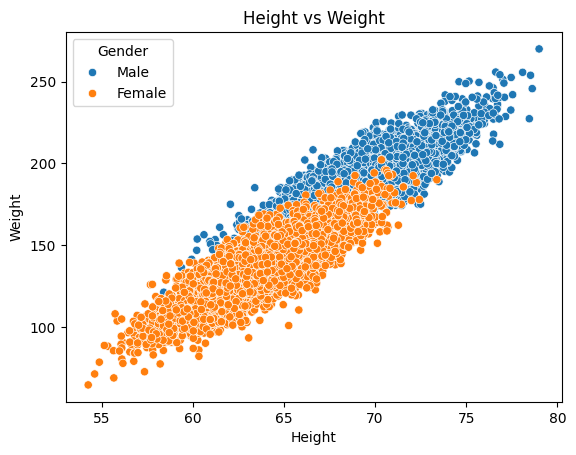

In [7]:
sns.scatterplot(x="Height", y="Weight", hue="Gender", data=df)
plt.title("Height vs Weight")
plt.show()


In [8]:
for col in ["Height", "Weight"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, "outliers:", outliers.shape[0])


Height outliers: 8
Weight outliers: 1


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

df.head()


,Gender,Height,Weight
0,1,73.847017,241.893563
1,1,68.781904,162.310473
2,1,74.110105,212.740856
3,1,71.730978,220.042470
4,1,69.881796,206.349801


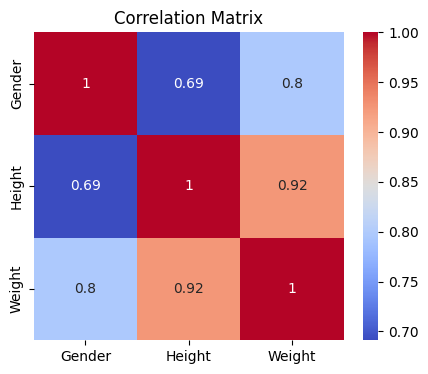

In [10]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [11]:
X = df.drop("Weight", axis=1)
y = df["Weight"]

X, y


(      Gender     Height
 0          1  73.847017
 1          1  68.781904
 2          1  74.110105
 3          1  71.730978
 4          1  69.881796
 ...      ...        ...
 9995       0  66.172652
 9996       0  67.067155
 9997       0  63.867992
 9998       0  69.034243
 9999       0  61.944246
 
 [10000 rows x 2 columns],
 0       241.893563
 1       162.310473
 2       212.740856
 3       220.042470
 4       206.349801
            ...    
 9995    136.777454
 9996    170.867906
 9997    128.475319
 9998    163.852461
 9999    113.649103
 Name: Weight, Length: 10000, dtype: float64)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((8000, 2), (2000, 2))

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [15]:
models = {}
mae = {}
rmse = {}
r2 = {}


In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

models["Linear Regression"] = pred_lr
mae["Linear Regression"] = mean_absolute_error(y_test, pred_lr)
rmse["Linear Regression"] = np.sqrt(mean_squared_error(y_test, pred_lr))
r2["Linear Regression"] = r2_score(y_test, pred_lr)

mae["Linear Regression"], rmse["Linear Regression"], r2["Linear Regression"]


(7.962168764049686, 10.062021490244044, 0.9033321846361925)

In [17]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

pred_knn = knn.predict(X_test_scaled)

models["KNN"] = pred_knn
mae["KNN"] = mean_absolute_error(y_test, pred_knn)
rmse["KNN"] = np.sqrt(mean_squared_error(y_test, pred_knn))
r2["KNN"] = r2_score(y_test, pred_knn)

mae["KNN"], rmse["KNN"], r2["KNN"]


(8.780612537449112, 11.084260550618309, 0.8826927443915704)

In [18]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

models["Decision Tree"] = pred_dt
mae["Decision Tree"] = mean_absolute_error(y_test, pred_dt)
rmse["Decision Tree"] = np.sqrt(mean_squared_error(y_test, pred_dt))
r2["Decision Tree"] = r2_score(y_test, pred_dt)

mae["Decision Tree"], rmse["Decision Tree"], r2["Decision Tree"]


(11.138278536171333, 14.042302780504372, 0.8117269800142274)

In [19]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

models["Random Forest"] = pred_rf
mae["Random Forest"] = mean_absolute_error(y_test, pred_rf)
rmse["Random Forest"] = np.sqrt(mean_squared_error(y_test, pred_rf))
r2["Random Forest"] = r2_score(y_test, pred_rf)

mae["Random Forest"], rmse["Random Forest"], r2["Random Forest"]


(9.521030269835444, 12.057594868236771, 0.8611861504869694)

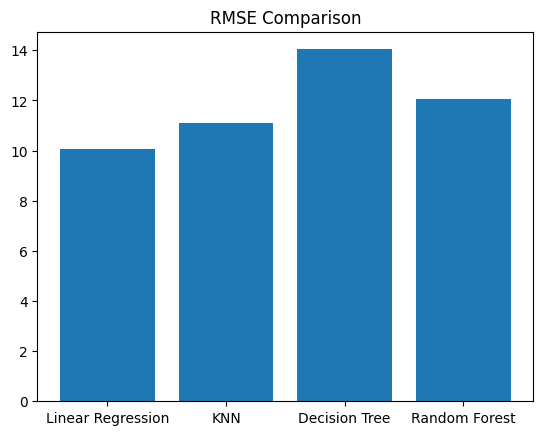

In [20]:
plt.figure()
plt.bar(rmse.keys(), rmse.values())
plt.title("RMSE Comparison")
plt.show()


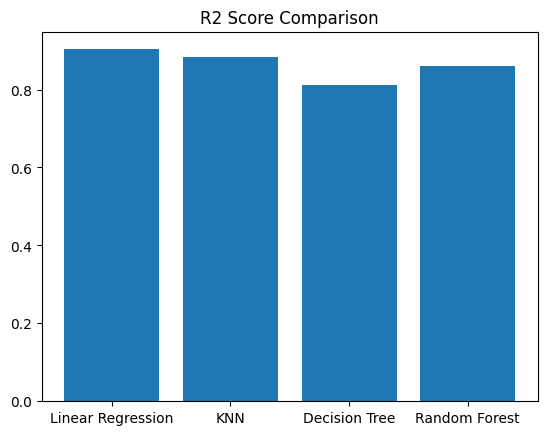

In [21]:
plt.figure()
plt.bar(r2.keys(), r2.values())
plt.title("R2 Score Comparison")
plt.show()


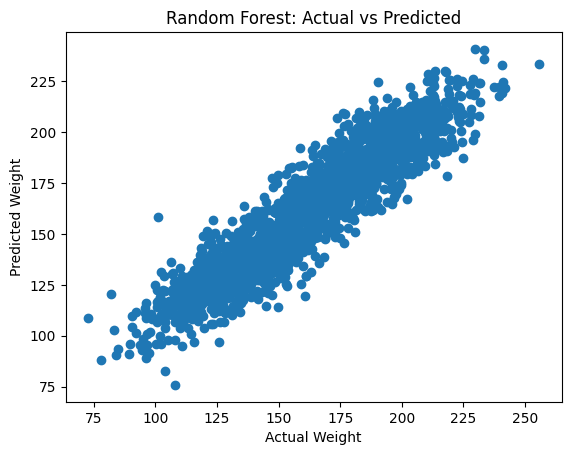

In [22]:
plt.scatter(y_test, pred_rf)
plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Random Forest: Actual vs Predicted")
plt.show()


In [23]:
results = pd.DataFrame({
    "Model": mae.keys(),
    "MAE": mae.values(),
    "RMSE": rmse.values(),
    "R2": r2.values()
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,7.962169,10.062021,0.903332
1,KNN,8.780613,11.084261,0.882693
2,Decision Tree,11.138279,14.042303,0.811727
3,Random Forest,9.521030,12.057595,0.861186
